In [1]:
import torch
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
print ("PyTorch version:", torch.__version__)
print ("CUDA available:", torch.cuda.is_available())
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print ("Using device:", device)
print ("Torchvision version:", torch.__version__)
# print ("Matplotlib version:", plt.__version__)
print ("NumPy version:", torch.__version__)
print ("All libraries imported successfully!")

PyTorch version: 2.3.1+cpu
CUDA available: False
Using device: cpu
Torchvision version: 2.3.1+cpu
NumPy version: 2.3.1+cpu
All libraries imported successfully!


In [ ]:
# Data loading function

def load_data(data_dir='d:\\VSCode\\Working place\\MY_ML_project\\Data\\raw\\TB_Chest_Radiography_Database', batch_size=32, train_ratio=0.8):
    full_data = datasets.ImageFolder(data_dir)

    train_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.Grayscale(num_output_channels=1),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5], std=[0.5])
    ])

    val_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.Grayscale(num_output_channels=1),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5], std=[0.5])
    ])

    train_size = int(train_ratio * len(full_data))
    val_size = len(full_data) - train_size

    train_dataset, val_dataset = random_split(full_data, [train_size, val_size])
    train_dataset.dataset.transform = train_transform
    val_dataset.dataset.transform = val_transform

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=True)

    return train_loader, val_loader, train_size, val_size

train_loader, val_loader, train_size, val_size = load_data()

In [6]:
import numpy as np
print(np.__version__)


1.26.4


In [7]:
import sys
print(sys.executable)


d:\Python 3.10.11\python.exe


In [8]:
import sys
print(sys.executable)

import numpy
print("NumPy:", numpy.__version__)

import torch
print("Torch:", torch.__version__)

import torchvision
print("Torchvision:", torchvision.__version__)


d:\Python 3.10.11\python.exe
NumPy: 1.26.4
Torch: 2.3.1+cpu
Torchvision: 0.18.1+cpu


In [9]:
from PIL import Image
from torchvision import transforms

img = Image.new("RGB", (64, 64))
t = transforms.ToTensor()
tensor = t(img)

print(tensor.shape)


torch.Size([3, 64, 64])


In [10]:
# filepath: d:\VSCode\Working place\MY_ML_project\Data\Task01\tb-cnn-pytorch.ipynb
# ...existing code...
if len(train_dataset) > 0:
    data, out = next(iter(train_loader))
    print(data.shape)
    print(out.shape)
else:
    print("Dataset is empty. Check the data folder structure.")
# ...existing code...

torch.Size([32, 1, 224, 224])
torch.Size([32])


In [11]:
# data, out = next(iter(train_loader))
# print(data.shape)
# print(out.shape)

In [12]:
class TBCNN(nn.Module):
    def __init__(self):
        super(TBCNN, self).__init__()
        self.conv1 = nn.Conv2d(1,16, kernel_size = 3, stride = 1, padding = 0)
        self.conv2 = nn.Conv2d(16,32, kernel_size = 3, stride = 1, padding = 0)
        self.conv3 = nn.Conv2d(32,128, kernel_size = 3, stride = 1, padding = 0)

        self.gap = nn.AdaptiveAvgPool2d((1,1))

        # self.fc1 = nn.Linear(128,128)
        self.fc2 = nn.Linear(128,32)
        # self.fc3 = nn.Linear(64,32)

        self.fc4 = nn.Linear(32,1)
        
        self.flatten = nn.Flatten()
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(2,2)

    def forward(self, x):
        x = self.relu(self.conv1(x))
        x = self.relu(self.conv2(x))
        x = self.pool(x)
        x = self.relu(self.conv3(x))
        
        x = self.gap(x)
        x = self.flatten(x)
        # x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        # x = self.relu(self.fc3(x))
        
        x = self.fc4(x)
        return x

In [13]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = TBCNN().to(device)

#criterion = nn.BCELoss()
# Assuming you are doing binary classification and your model's final layer 
# does NOT have a sigmoid, which is ideal for BCEWithLogitsLoss
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(),lr = 0.001)

num_epochs = 10
train_losses, val_losses = [], []
train_accs, val_accs = [], []

In [14]:
pip install torchsummary

In [15]:
from torchsummary import summary

summary(model, input_size=(1, 224, 224))


----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 16, 222, 222]             160
              ReLU-2         [-1, 16, 222, 222]               0
            Conv2d-3         [-1, 32, 220, 220]           4,640
              ReLU-4         [-1, 32, 220, 220]               0
         MaxPool2d-5         [-1, 32, 110, 110]               0
            Conv2d-6        [-1, 128, 108, 108]          36,992
              ReLU-7        [-1, 128, 108, 108]               0
 AdaptiveAvgPool2d-8            [-1, 128, 1, 1]               0
           Flatten-9                  [-1, 128]               0
           Linear-10                   [-1, 32]           4,128
             ReLU-11                   [-1, 32]               0
           Linear-12                    [-1, 1]              33
Total params: 45,953
Trainable params: 45,953
Non-trainable params: 0
---------------------------------

In [ ]:
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct , total = 0,0 

    for images, labels in train_loader:
        #labels size = (32)
        # output size = (32,1) -- > (32) squeeze
        images, labels = images.to(device), labels.to(device).float().unsqueeze(1) ##(32,1)

        optimizer.zero_grad()

        output = model(images)

        loss = criterion(output, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        preds = torch.sigmoid(output)
        predicted = (preds > 0.5).float()
        correct += (predicted == labels).sum().item()
        total += labels.size(0)
    train_acc = 100 * correct / total 
    train_loss = running_loss / len(train_loader)

    model.eval()
    val_loss = 0
    correct , total = 0,0 
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device).float().unsqueeze(1) ##(32,1)
    
            output = model(images)
    
            loss = criterion(output, labels) 
            val_loss += loss.item()
    
            preds = torch.sigmoid(output)
            predicted = (preds > 0.5).float()
            correct += (predicted == labels).sum().item()
            total += labels.size(0)
            
        val_acc = 100 * correct / total 
        val_loss = val_loss / len(val_loader)
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print(f"Epoch | {epoch + 1} | "
         f"Train loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | Val loss: {val_loss: .4f} | Val acc: {val_acc:.2f}%")

In [ ]:
torch.save(model.state_dict(), "TBCNN_model.pth")

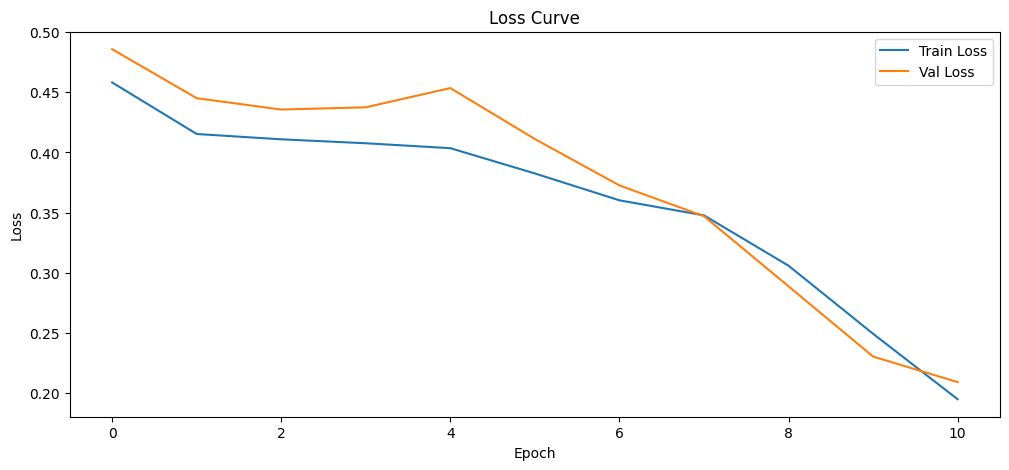

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Curve')
plt.legend()
plt.show()

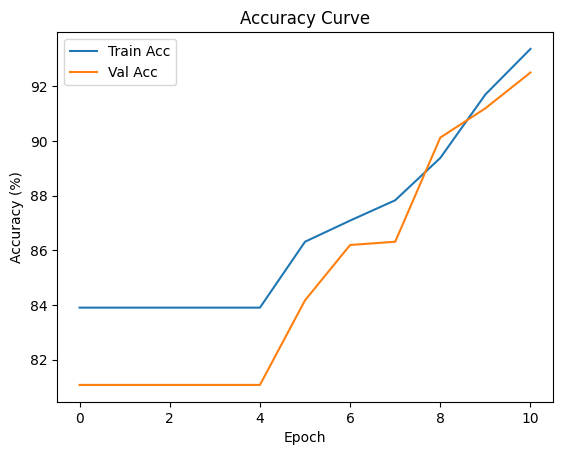

In [ ]:
plt.plot(train_accs, label='Train Acc')
plt.plot(val_accs, label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Accuracy Curve')
plt.legend()
plt.show()

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

model.eval()
all_labels = []
all_preds = []

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.float().to(device)
        outputs = model(images)
        preds = torch.sigmoid(outputs)
        preds = (outputs > 0.5).float()
        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())

print("Classification Report:")
print(classification_report(all_labels, all_preds, target_names=['Normal', 'Tuberculosis']))


Classification Report:
              precision    recall  f1-score   support

      Normal       0.92      0.99      0.96       681
Tuberculosis       0.96      0.63      0.76       159

    accuracy                           0.93       840
   macro avg       0.94      0.81      0.86       840
weighted avg       0.93      0.93      0.92       840



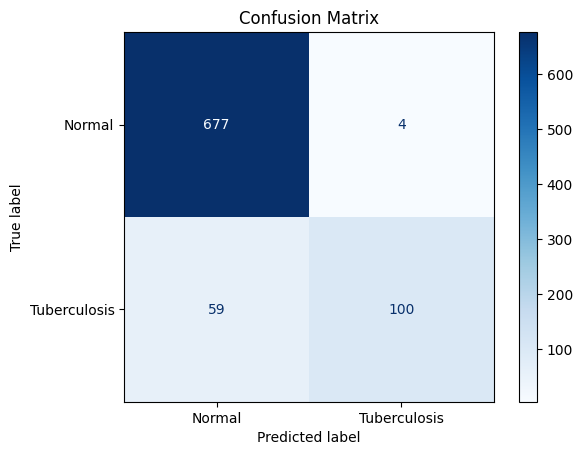

In [ ]:
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Tuberculosis'])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()
